# Model Training Script

This script reads in CFSR data from 1979 - 2010 and trains machine learning models to target CNBS from L2SWBM across the 5 Great Lakes simultaeously.

In [150]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF, Matern, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor as skRFR
import xgboost as xgb
import tensorflow as tf
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble
import sys
import re
import os

In [151]:
sys.path.append(os.path.abspath('../../'))
from src.data_processor import CFSTransformer
from src.data_loader import DataLoader
from src.data_processor import SeasonalCycleProcessor

## User Input

In [152]:
# This is the directory where you cloned the repo
local_path = '/Users/ljob/Desktop/'

input_dir = local_path + 'cnbs-predictor/data/'

# Path to GLSEA SST data
glsea_data = input_dir + 'glsea/oisst_sst_1981-2024.csv'

# Path to CFSR SWE data
cfsr_swe_data = input_dir + 'cfsr/CFSR_SWE_Basin_mm.csv'

## Begin Script

## Feature Construction Workflow

This script prepares the feature dataset for model training by integrating precipitation, evaporation, air temperature, and lake surface temperature data. The workflow is as follows:

### 1. Read Reanalysis Data from CFSR
- **Precipitation (PCP, mm)**
- **Evaporation (EVAP, mm)** 
- **Air Temperature (TMP, K)** 

### 2. Assemble Feature Matrix (`X`)
- Construct a DataFrame containing lake- and land-specific values for each Great Lake (Superior, Michigan-Huron, Erie, Ontario).  
- Variables include precipitation, evaporation, and air temperature for both **over-lake** and **over-land** domains.

### 3. Create Forecast-Like Features
- Apply `CFSProcessor.shift_variables` to generate lead times from **0 to 9 months** for each variable to replicate a 9-month CFS forecast.

### 4. Include Seasonality
- Extract the calendar month from the datetime index.  
- Convert the month into **one-hot encoded categorical variables** (`month_1` through `month_12`).

### 5. Reorder Features
- Columns are reorganized to ensure consistent ordering:  
  1. Month indicators (`month_1` … `month_12`)  
  2. Basin-specific variables for precipitation, evaporation, and air temperature across all lead times (`mo0` … `mo9`).

### 6. Include Lake Surface Temperature (GLSEA SST)
- Load Great Lakes Surface Environmental Analysis (GLSEA) SST data (`oisst_sst_1981-2024.csv`) in Kelvin.  
- Merge SST with the reorganized predictor matrix to produce the final feature dataset (`X_merged`).

### 7. Feature Table Example

| Feature Category | Example Feature Names (Lead Times 0–9) |
|-----------------|----------------------------------------|
| SST | `superior_sst` |
| Month Indicators | `month_1, month_2, ..., month_12` |
| Precipitation (Lake) | `superior_lake_precipitation_mo0, ..., mo9`|
| Precipitation (Land) | `superior_land_precipitation_mo0, ..., mo9` |
| Evaporation (Lake) | `superior_lake_evaporation_mo0, ..., mo9` |
| Evaporation (Land) | `superior_land_evaporation_mo0, ..., mo9` |
| Air Temperature (Lake) | `superior_lake_air_temperature_mo0, ..., mo9` |
| Air Temperature (Land) | `superior_land_air_temperature_mo0, ..., mo9` |

In [153]:
# Split dataset by date ranges into training and testing sets
train_start_date = '1979-01-01'
train_end_date = '2017-12-31'

# Testing dataset
val_start_date = '2018-01-01'
val_end_date = '2024-01-01'

# Training and validation slices
train_slice = slice(train_start_date, train_end_date)
val_slice   = slice(val_start_date, val_end_date)

# Read in data from CFSR
data = pd.read_csv(input_dir+'cfsr/CFSR_archived_1979-2024.csv',sep=',')

# Features
X = pd.DataFrame({
    'date': data['date'],
    'superior_lake_precipitation':  data['superior_lake_precipitation'],
    'michigan-huron_lake_precipitation': data['michigan-huron_lake_precipitation'],
    'erie_lake_precipitation': data['erie_lake_precipitation'],
    'ontario_lake_precipitation': data['ontario_lake_precipitation'],
    'superior_land_precipitation': data['superior_land_precipitation'],
    'michigan-huron_land_precipitation': data['michigan-huron_land_precipitation'],
    'erie_land_precipitation': data['erie_land_precipitation'],
    'ontario_land_precipitation': data['ontario_lake_precipitation'],
    'superior_lake_evaporation': data['superior_lake_evaporation'],
    'michigan-huron_lake_evaporation': data['michigan-huron_lake_evaporation'],
    'erie_lake_evaporation': data['erie_lake_evaporation'],
    'ontario_lake_evaporation': data['ontario_lake_evaporation'],
    'superior_land_evaporation': data['superior_land_evaporation'],
    'michigan-huron_land_evaporation': data['michigan-huron_land_evaporation'],
    'erie_land_evaporation': data['erie_land_evaporation'],
    'ontario_land_evaporation': data['ontario_lake_evaporation'],
    'superior_lake_air_temperature': data['superior_lake_air_temperature'],
    'michigan-huron_lake_air_temperature': data['michigan-huron_lake_air_temperature'],
    'erie_lake_air_temperature': data['erie_lake_air_temperature'],
    'ontario_lake_air_temperature': data['ontario_lake_air_temperature'],
    'superior_land_air_temperature': data['superior_land_air_temperature'],
    'michigan-huron_land_air_temperature': data['michigan-huron_land_air_temperature'],
    'erie_land_air_temperature': data['erie_land_air_temperature'],
    'ontario_land_air_temperature': data['ontario_lake_air_temperature']
})

# Set the index by date
X = X.set_index(pd.to_datetime(X['date'])).drop(columns='date')

In [154]:
# Load in GLSEA SST data and merge with features
dataloader = DataLoader()
df_sst_k = dataloader.glsea(glsea_data, units='K')

X_merged = pd.merge(df_sst_k, X, left_index=True, right_index=True, how='inner')

In [155]:
#snodas = load_snodas(local_path+'DoD SAFE-8WBhd9qAMBPtYPKG/Snodas/SWE.SNODAS.GL.csv')
snodas = pd.read_csv(cfsr_swe_data,sep=',')
snodas = snodas.set_index(pd.to_datetime(snodas['date'])).drop(columns='date')
snodas = snodas.rename(columns={'superior': 'superior_swe', 
                                'michigan-huron': 'michigan-huron_swe', 
                                'erie': 'erie_swe', 
                                'ontario': 'ontario_swe'})

In [156]:
X_merged_2 = pd.merge(snodas, X_merged, left_index=True, right_index=True, how='inner')

## NEW: Call seasonal cycle processor to convert inputs to anomalies

In [157]:
# Fit seasonal cycle
scp_X = SeasonalCycleProcessor().fit(
    X_merged_2,
    var_list=list(X_merged_2.columns),
    baseline_time=train_slice,
    baseline_definition={
        "train_start" : train_start_date,
        "train_end" : train_end_date
    }
)
paths = scp_X.save("/Users/ljob/Desktop/cnbs-predictor/data/input/climatology/inputs")

# Transform the full dataset
X_anom = scp_X.transform(X_merged_2)
print(X_anom)


       superior_swe  michigan-huron_swe      erie_swe  ontario_swe  \
month                                                                
1         26.720805        1.468741e+01  5.120954e+00     9.265363   
2         41.955850        2.402138e+01  1.005364e+01    17.050085   
3         40.699109        2.142826e+01  6.860022e+00    12.150580   
4         21.763697        7.191674e+00  7.957798e-01     2.126885   
5          1.525131        8.278369e-01  7.518580e-03     0.109520   
6          0.054791        1.334219e-02  1.460134e-09     0.005330   
7          0.003603        2.065827e-04  0.000000e+00     0.000000   
8          0.000000        0.000000e+00  4.400695e-04     0.000000   
9          0.000101        5.055185e-09  0.000000e+00     0.000000   
10         0.002639        2.717003e-03  2.428706e-04     0.000120   
11         0.926047        1.654383e-01  5.481230e-02     0.075298   
12         8.620437        3.205748e+00  7.423771e-01     1.843573   

       superior_sst

In [158]:
# Columns ending with '_sst' OR '_swe'
ssts_swe = X_anom.filter(regex='(_sst$|_swe$)')

# Columns NOT ending with '_sst' OR '_swe'
non_ssts_swe = X_anom.loc[
    :,
    ~(X_anom.columns.str.endswith('_sst') |
      X_anom.columns.str.endswith('_swe'))
]

# Shift the features to create lead times from 0 to 9 months
X_temp = CFSTransformer(non_ssts_swe).shift_variables(lag=0, lead=10)

X_shifted = pd.merge(ssts_swe, X_temp, left_index=True, right_index=True, how='inner')

Below is an example plot of the anomalies and a fitted seasonal cycle.

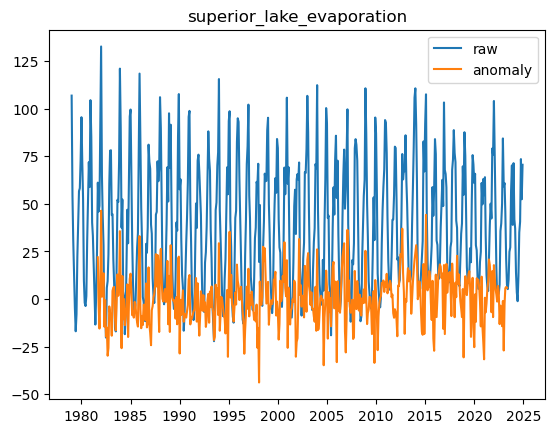

In [159]:
import matplotlib.pyplot as plt

var = "superior_lake_evaporation"

plt.figure()
plt.plot(X[var], label="raw")
plt.plot(X_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

Now that we have the anomalies in `X_anom`, we resume the existing feature construction workflow

In [174]:
X_time = CFSTransformer(X_shifted).add_time_features()

feature_column_order = (
    ['time', 'month_sin', 'month_cos'] +
    ['superior_swe', 'michigan-huron_swe', 'erie_swe', 'ontario_swe'] +
    ['superior_sst', 'michigan-huron_sst', 'erie_sst', 'ontario_sst'] +
    [
        f'{lake}_{surface_type}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for surface_type in ['lake', 'land']
        for comp in ['precipitation', 'evaporation', 'air_temperature']
        for m in range(10) #from 0 to 9, representing the 10 months of lead time
    ]
)

# Reorder the columns to match the specified order
X_reorg = X_time[feature_column_order]

## Target Construction Workflow

This script prepares the target dataset for model training, including precipitation, evaporation, runoff, and net basin supply (NBS) for each Great Lake. The workflow is as follows:

### 1. Load L2SWBM Data
- Source: [L2SWBM dataset](https://zenodo.org/records/13883098)  
- Required file format for each lake (erie, miHuron, ontario, superior):  
  - Evaporation: `{lake}Evap_MonthlyRun.csv`  
  - Precipitation: `{lake}Precip_MonthlyRun.csv`  
  - Runoff: `{lake}Runoff_MonthlyRun.csv`  
- Each loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `{lake}_{component}_obs` (e.g., `erie_precipitation_obs`) for each lake and component.

### 2. Load GLCC Data
- Source: Great Lakes Coordinating Committee (GLCC)  
- Required file format for each lake (Erie, MichiganHuron, Ontario, Superior):  
  - `Lake{lake}_MonthlyNetBasinSupply_1900to2025.csv`  
- Loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `lake_nbs_obs` for each lake.

### 3. Assemble Target Matrix (`targets`)
- Combine L2SWBM components (precipitation, evaporation, runoff) with GLCC NBS for each lake into a single DataFrame.  
- Column naming convention: `{lake}_target_{component}` (e.g., `superior_target_evaporation`).  
- Only keep rows where **all target values are available** by dropping any rows with missing data.

### 4. Create Forecast-Like Lead Variables
- Apply `CFSProcessor.shift_variables` to generate **lead versions of all targets**, to minic the targeted **12-month forecast horizon** (lead times 0–11).

### 5. Reorder Target Columns
- Columns are organized to ensure a consistent structure for modeling:  

```text
superior_target_precipitation_mo0 … mo11
superior_target_evaporation_mo0 … mo11
superior_target_runoff_mo0 … mo11
superior_target_nbs_mo0 … mo11
michigan-huron_target_precipitation_mo0 … mo11
michigan-huron_target_evaporation_mo0 … mo11
...
ontario_target_nbs_mo0 … mo11


In [162]:
# Load L2SWBM data
l2 = dataloader.l2swbm(input_dir + 'l2swbm/')

# Load GLCC data
glcc = dataloader.glcc(input_dir + 'glcc/', units='mm')

# Targets are the components (P, E, R) fro L2SWBM and NBS from GLCC
targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evaporation_obs'],
    'superior_target_precipitation': l2['superior_precipitation_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evaporation_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precipitation_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evaporation_obs'],
    'erie_target_precipitation': l2['erie_precipitation_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evaporation_obs'],
    'ontario_target_precipitation': l2['ontario_precipitation_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs']
})

# The dataframes are merged by date so we need to drop rows with NaN values
# This ensures that we only keep rows where all target values are available
targets = targets.dropna()

targets_shifted = CFSTransformer(targets).shift_variables(lag=0, lead=12)

### Convert targets to anomalies from the seasonal cycle as well

In [163]:
# 1) Fit monthly climatology on TRAIN ONLY (avoid leakage)
scp_y = SeasonalCycleProcessor().fit(
    targets,
    var_list=list(targets.columns),          # explicit is good here
    baseline_time=train_slice,
    baseline_definition={
        "train_start": train_start_date,
        "train_end": train_end_date,
        "note": "targets climatology fit on training period only"
    },
)

# 2) Transform full targets to anomalies
targets_anom = scp_y.transform(targets)

scp_y.climatology.columns = [
    c.replace("_target", "") for c in scp_y.climatology.columns
]

# Save artifact so forecast notebook can load the same baseline
paths = scp_y.save("/Users/ljob/Desktop/cnbs-predictor/data/input/climatology/targets")

       superior_target_evaporation  superior_target_precipitation  \
month                                                               
1                       103.922230                      51.755641   
2                        58.874766                      34.955128   
3                        42.587684                      42.244615   
4                        16.323566                      56.792821   
5                         2.504305                      71.029231   
6                        -3.007454                      81.873846   
7                        -0.722389                      77.578205   
8                        15.746432                      75.816667   
9                        51.351828                      82.584103   
10                       73.727126                      76.761538   
11                       99.853890                      62.144615   
12                      118.657172                      56.633333   

       superior_target_runoff  su

Now we visualize the seasonal cycle and anomalies

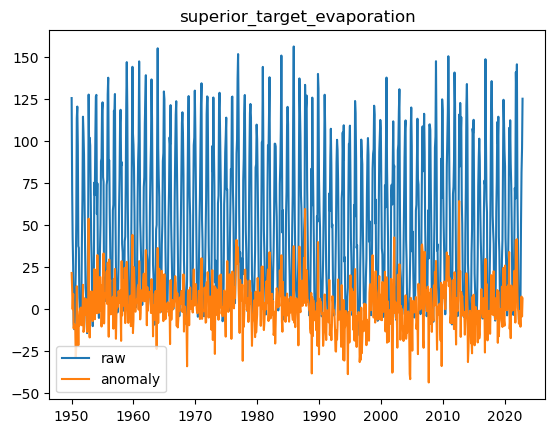

In [164]:
import matplotlib.pyplot as plt

var = "superior_target_evaporation"
plt.figure()
plt.plot(targets[var], label="raw")
plt.plot(targets_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

From here, we shift the targets to create lead variables, using targets_anom instead of targets

In [165]:
# Shift the targets to create lead variables
targets_lead = CFSTransformer(targets_anom).shift_variables(lag=0, lead=12)

# Define the target column order for the 12-month forecast
target_column_order =[
        f'{lake}_target_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]

# Reorganize the targets DataFrame to match the target column order
targets_reorg = targets_lead.reindex(columns=target_column_order)

## Align Features and Targets

This step ensures that the **features** and **target** datasets are aligned:  

### 1. Subset the reorganized target DataFrame (`targets_reorg`) to only include rows corresponding to the **dates present in the merged feature dataset** (`X_merged`).  
   - This guarantees that each row of features has a matching target for model training.  
   - The aligned target dataset is stored in `aligned_y`.

### 2. Print summary information for verification:  
   - **Number of features** (`X_merged.shape[1]`)  
   - **Number of target variables** (`aligned_y.shape[1]`)  

This alignment is crucial for ensuring consistent input-output pairing before training or forecasting.


In [166]:
print(X_reorg.head())

                time     month_sin     month_cos  superior_swe  \
date                                                             
1981-09-01 -1.726855 -1.000000e+00 -1.836970e-16     -0.000101   
1981-10-01 -1.719811 -8.660254e-01  5.000000e-01      0.016857   
1981-11-01 -1.712767 -5.000000e-01  8.660254e-01     -0.601132   
1981-12-01 -1.705723 -2.449294e-16  1.000000e+00      5.829989   
1982-01-01 -1.698679  5.000000e-01  8.660254e-01     37.860176   

            michigan-huron_swe   erie_swe  ontario_swe  superior_sst  \
date                                                                   
1981-09-01       -5.055185e-09   0.000000     0.000000      1.070541   
1981-10-01        1.918647e-03  -0.000243    -0.000120     -3.547838   
1981-11-01        1.604539e-01   0.006353    -0.075298     -1.424054   
1981-12-01        1.232978e+00  -0.263339    -0.943694     -0.003243   
1982-01-01        2.019809e+01  12.751777     8.304166      0.314722   

            michigan-huron_sst  

In [167]:
# Make sure the features and target indices/dates align
aligned_X, aligned_y = X_reorg.align(targets_reorg, join='inner', axis=0)
print(f'Number of Features: {aligned_X.shape[1]}')
print(f'Number of Targets: {aligned_y.shape[1]}')

Number of Features: 251
Number of Targets: 192


## Train-Test Split by Date

This step divides the dataset into **training** and **testing** subsets based on date ranges, rather than random sampling, to **preserve seasonal and temporal structure**:  

### 1. **Training Set (≈80% of data)**  
   - Start: January 1982  
   - End: December 2005  
   - `X_train` and `y_train` contain features and targets within this range.  

### 2. **Testing/Validation Set (≈20% of data)**  
   - Start: January 2006  
   - End: January 2011  
   - `X_test` and `y_test` contain features and targets within this range.  

This chronological split ensures that the model is evaluated on **future data**, maintaining realistic forecasting conditions and seasonal patterns.


In [168]:
X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]
X_test = aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

## Feature and Target Standardization

This step standardizes the features and targets to improve model training and convergence:  

### 1. **Define Scalers**  
   - `x_scaler` and `y_scaler` are instances of `StandardScaler` from `scikit-learn`.  

### 2. **Fit and Transform Training Data**  
   - The scalers are **fit only on the training data** to avoid data leakage.  
   - `X_train_scaled` and `y_train_scaled` contain standardized training features and targets.  

### 3. **Transform Testing Data**  
   - Apply the same fitted scalers to the testing data (`X_test_scaled` and `y_test_scaled`) to ensure consistent scaling.  

### 4. **Save Scalers for Future Use**  
   - The fitted scalers are saved using `joblib.dump` so they can be applied during the **prediction phase** on new data, maintaining the same scaling.


In [169]:
# Define the scaler we want to use
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Standardize the data
# This will scale the features and targets between 0 and 1
# It is important to fit the scaler on the training data and then transform both train and test data
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Save the scalers to use later during the prediction phase
joblib.dump(x_scaler, input_dir + 'input/scalers/x_scaler_anom.joblib')
joblib.dump(y_scaler, input_dir + 'input/scalers/y_scaler_anom.joblib')

['/Users/ljob/Desktop/cnbs-predictor/data/input/scalers/y_scaler_anom.joblib']

## Gaussian Process Regression (GPR) Model Setup, Training and Evaluation

This step defines, trains, and evaluates a **Gaussian Process Regression (GPR)** model using the preprocessed features and targets.  

### 1. Kernel Selection
- Several kernel options are explored for modeling:  
  - **Basic kernel:** `ConstantKernel * RBF`  
  - **Matt's optimal kernel:** `1.0 * Matern(nu=1.5) * RationalQuadratic()` (currently used)  
  - Optional seasonal components: `ExpSineSquared` for modeling periodicity, or combinations of `RBF`, `Matern`, and `RationalQuadratic`.  

### 2. Model Definition
- Initialize the GPR model with the selected kernel.  
- Parameters:  
  - `alpha=0.1` → observation noise level  
  - `n_restarts_optimizer=10` → number of restarts for kernel hyperparameter optimization  
  - `random_state=42` → ensures reproducibility  

### 3. Model Training
- Fit the GPR model on the **scaled training data** (`X_train_scaled` and `y_train_scaled`).  
- Save the trained model using `joblib` for future use.

### 4. Predictions and Evaluation
- Predict on the **scaled testing features** (`X_test_scaled`) and obtain uncertainty estimates (`sigma`).  
- Compute **R² score** on the testing data to evaluate model performance:  
  ```python
  r2 = r2_score(y_test_scaled, y_pred_GP)

(The function below should be added to the data processor)

In [170]:
_MO_RE = re.compile(r"_mo(\d+)$")

def add_climatology_back_leadwide(
    df_anom_leadwide: pd.DataFrame,
    scp_y: "SeasonalCycleProcessor",
    strict: bool = False,
) -> pd.DataFrame:
    """
    Convert lead-wide anomaly targets to lead-wide absolute targets by adding a monthly climatology.

    This is designed for targets that have already been shifted into lead form, where each column
    ends with `_mo{k}` and the DataFrame index represents the *initialization* date.

    Month alignment rule
    --------------------
    For a given init date `t` and lead `k` months, the verifying month is:
        verifying_month = month(t + k months)

    Parameters
    ----------
    df_anom_leadwide : pd.DataFrame
        Anomaly DataFrame indexed by init date (must be a DatetimeIndex).
        Columns must end with `_mo{k}` where k is lead in months, e.g.:
            'superior_target_precipitation_mo0', ..., '..._mo11'

        Values must be in anomaly units (i.e., NOT standardized).

    scp_y : SeasonalCycleProcessor
        A fitted seasonal-cycle processor with attribute `climatology`:
            - index: months 1..12 (int)
            - columns: base (unshifted) variable names, e.g. 'superior_target_precipitation'
            - values: monthly climatological means in absolute units

    strict : bool, default False
        If True, raise an error if any column does not match the `_mo{k}` pattern.

    Returns
    -------
    pd.DataFrame
        Same shape/columns/index as `df_anom_leadwide`, but in absolute units
        (monthly climatology added back to each lead column).
    """
    if not isinstance(df_anom_leadwide.index, pd.DatetimeIndex):
        raise ValueError("df_anom_leadwide must have a DatetimeIndex (init dates).")

    if not hasattr(scp_y, "climatology"):
        raise AttributeError("scp_y must have a `climatology` attribute (fit the processor first).")

    clim = scp_y.climatology

    if not isinstance(clim, pd.DataFrame):
        raise TypeError("scp_y.climatology must be a pandas DataFrame (month x base_var).")

    # Optional sanity check: months should be 1..12
    # (Don't force order; just ensure membership.)
    expected_months = set(range(1, 13))
    clim_months = set(pd.Index(clim.index).astype(int).tolist())
    if not expected_months.issubset(clim_months):
        raise ValueError(
            "scp_y.climatology index must include months 1..12. "
            f"Got: {sorted(clim_months)[:15]}..."
        )

    out = df_anom_leadwide.copy()
    idx = out.index

    for col in out.columns:
        m = _MO_RE.search(col)
        if m is None:
            if strict:
                raise ValueError(f"Column '{col}' does not end with _mo{{k}}.")
            continue

        lead = int(m.group(1))
        base = _MO_RE.sub("", col)  # strip _mo{k}

        if base not in clim.columns:
            raise KeyError(
                f"Base variable '{base}' not found in climatology columns. "
                "This usually means climatology was fit on different variable names."
            )

        verifying_month = (idx + pd.DateOffset(months=lead)).month  # 1..12
        out[col] = out[col].to_numpy() + clim.loc[verifying_month, base].to_numpy()

    return out

In [171]:
# Testing Different Kernels
# Basic kernel using ConstantKernel:
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Matt's optimal kernel: 
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

#kernel = 1.0 * Matern(length_scale=50.0, nu=1.5, length_scale_bounds=(1e-10, 1e3)) \
#         * RationalQuadratic(alpha=0.0001, length_scale=.01, length_scale_bounds=(1e-10, 1e3))

# Test to add a seasonality component:
#period = 3.0  # Period of the season
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + ExpSineSquared(length_scale=1.0, periodicity=period, periodicity_bounds=(1e-2, 1e2))

# Set up the model
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=10, random_state=42)

# Fit the model
gpr.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(gpr, input_dir + 'input/models/GP_trained_model_anom.joblib')

# Predictions
y_pred_GP, sigma = gpr.predict(X_test_scaled, return_std=True)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_GP)

print(f"R² Score: {r2:.4f}")
# Optimized kernel after training
print("Optimized Kernel:", gpr.kernel_)

# Kernel hyperparameters
print("Kernel Hyperparameters:", gpr.kernel_.theta)

R² Score: 0.3291
Optimized Kernel: 3.41**2 * Matern(length_scale=100, nu=1.5) * RationalQuadratic(alpha=0.000673, length_scale=1e-05)
Kernel Hyperparameters: [  2.45077945   4.60778139  -7.30374557 -11.51292546]


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [172]:
def unscale_to_df(y_std, scaler, index, columns):
    return pd.DataFrame(scaler.inverse_transform(y_std), index=index, columns=columns)

def r2_flat(a, b):
    return r2_score(a.to_numpy().ravel(), b.to_numpy().ravel())

# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_GP,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.29056696131540516


KeyError: "Base variable 'superior_target_precipitation' not found in climatology columns. This usually means climatology was fit on different variable names."

In [ ]:
import xgboost as xgb

# Create the XGBoost regressor 
xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'  # for regression
)

# Train the model
xgb.fit(X_train_scaled, y_train_scaled)

# Predict on the test set
y_pred_XGB = xgb.predict(X_test_scaled)

# Save the trained model
joblib.dump(xgb, input_dir + 'input/models/XGB_trained_model_anom.joblib')

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_XGB)

print(f"R² Score: {r2:.4f}")

R² Score: 0.2811


In [ ]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_XGB,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.26304260177545147
R² (absolute, reconstructed): 0.7285059272811205
R² (absolute, climatology-only): 0.6312143325986058


In [ ]:
## Random Forest Regressor Model:

# Initialize RandomForestRegressor
rfr_model = skRFR(random_state=42)

# Train the model
trained_RFR = rfr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(trained_RFR, input_dir + 'input/models/RF_trained_model_anom.joblib')

# Predict on the test set
y_pred_RFR = trained_RFR.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_RFR)

print(f"R² Score: {r2:.4f}")

R² Score: 0.0789


In [ ]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_RFR,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.12227525957538088
R² (absolute, reconstructed): 0.6766474356888228
R² (absolute, climatology-only): 0.6312143325986058


(435, 251) (435, 192)
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0427 - mae: 0.7803 - val_loss: 1.1430 - val_mae: 0.8079
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9622 - mae: 0.7439 - val_loss: 1.1213 - val_mae: 0.7978
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9410 - mae: 0.7345 - val_loss: 1.1179 - val_mae: 0.7957
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9172 - mae: 0.7249 - val_loss: 1.1237 - val_mae: 0.7969
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8880 - mae: 0.7133 - val_loss: 1.1345 - val_mae: 0.8010
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8533 - mae: 0.6993 - val_loss: 1.1313 - val_mae: 0.8006
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8171 - mae: 0.6858 - val_loss: 1.1182 - val_mae: 0.7965
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7791 - mae: 0.6706 - val_loss: 1.1024 - val_mae: 0.7918
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

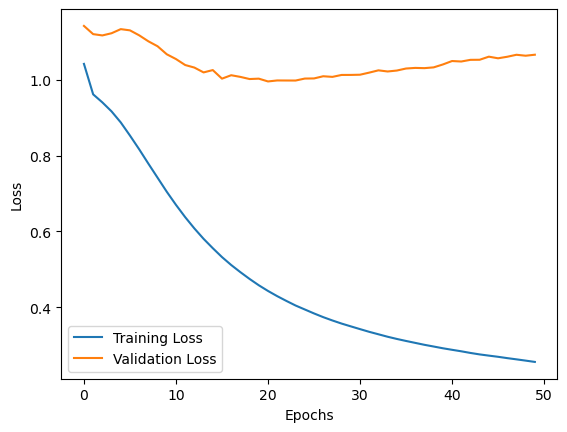

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
R² Score: -0.0856


In [ ]:
## Neural Network ##

# Define the neural network architecture
nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1])
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Using mean squared error (mse) as the loss function

print(X_train_scaled.shape, y_train_scaled.shape)
# Fit the model to the training data
history = nn_model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=1)#, callbacks=[early_stopping])

# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
joblib.dump(nn_model, input_dir + 'input/models/NN_trained_model_anom.joblib')

# Predict on the test set
y_pred_NN = nn_model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_NN)

print(f"R² Score: {r2:.4f}")

In [ ]:
y_gp_anom = unscale_to_df(y_pred_GP, y_scaler, y_test.index, y_test.columns)
y_gp_abs = add_climatology_back_leadwide(y_gp_anom, scp_y)
y_gp_abs['model'] = 'GP'

y_rf_anom = unscale_to_df(y_pred_RFR, y_scaler, y_test.index, y_test.columns)
y_rf_abs = add_climatology_back_leadwide(y_rf_anom, scp_y)
y_rf_abs['model'] = 'RFR'

y_nn_anom = unscale_to_df(y_pred_NN, y_scaler, y_test.index, y_test.columns)
y_nn_abs = add_climatology_back_leadwide(y_nn_anom, scp_y)
y_nn_abs['model'] = 'NN'

y_xgb_anom = unscale_to_df(y_pred_XGB, y_scaler, y_test.index, y_test.columns)
y_xgb_abs = add_climatology_back_leadwide(y_xgb_anom, scp_y)
y_xgb_abs['model'] = 'XGB'

df_all = pd.concat([y_gp_abs, y_rf_abs, y_nn_abs, y_xgb_abs], axis=0)

df_all = df_all.reset_index()
df_all = df_all.rename(columns={'date': 'cfs_run'})
df_all = df_all.rename(columns={'index': 'cfs_run'})
print(df_all)

       cfs_run  superior_target_precipitation_mo0  \
0   2018-01-01                          57.221763   
1   2018-02-01                          56.205797   
2   2018-03-01                          27.935686   
3   2018-04-01                          48.891597   
4   2018-05-01                          75.881465   
..         ...                                ...   
191 2021-09-01                          80.752513   
192 2021-10-01                          73.878592   
193 2021-11-01                          66.866242   
194 2021-12-01                          91.263350   
195 2022-01-01                          47.852160   

     superior_target_precipitation_mo1  superior_target_precipitation_mo2  \
0                            54.715863                          29.369535   
1                            30.201633                          46.631401   
2                            45.723619                          72.622758   
3                            76.735652                 

/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_4578/1546800753.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  y_gp_abs['model'] = 'GP'
/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_4578/1546800753.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  y_rf_abs['model'] = 'RFR'
/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_4578/1546800753.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

In [ ]:
# Step 1: Melt into long format
df_melted = df_all.melt(
    id_vars=['cfs_run', 'model'],
    var_name='variable',
    value_name='value'
)
print(df_melted)


         cfs_run model                           variable       value
0     2018-01-01    GP  superior_target_precipitation_mo0   57.221763
1     2018-02-01    GP  superior_target_precipitation_mo0   56.205797
2     2018-03-01    GP  superior_target_precipitation_mo0   27.935686
3     2018-04-01    GP  superior_target_precipitation_mo0   48.891597
4     2018-05-01    GP  superior_target_precipitation_mo0   75.881465
...          ...   ...                                ...         ...
37627 2021-09-01   XGB            ontario_target_nbs_mo11   31.247204
37628 2021-10-01   XGB            ontario_target_nbs_mo11   60.868974
37629 2021-11-01   XGB            ontario_target_nbs_mo11   79.281764
37630 2021-12-01   XGB            ontario_target_nbs_mo11  147.612277
37631 2022-01-01   XGB            ontario_target_nbs_mo11  191.181636

[37632 rows x 4 columns]


In [ ]:

# Step 2: Split into lake, variable, and month_offset
split_cols = df_melted['variable'].str.rsplit('_', n=2, expand=True)
df_melted['lake'] = split_cols[0].str.replace('_target', '', regex=False)
df_melted['variable'] = split_cols[1]
df_melted['month_offset'] = split_cols[2].str.replace('mo', '', regex=False).astype(int)

# Step 3: Compute forecast_month (vectorized, better)
df_melted['cfs_run'] = pd.to_datetime(df_melted['cfs_run'])
df_melted['forecast_month'] = (
    df_melted['cfs_run'].dt.to_period('M') +
    df_melted['month_offset']
).astype(str)
print(df_melted)


         cfs_run model       variable       value      lake  month_offset  \
0     2018-01-01    GP  precipitation   57.221763  superior             0   
1     2018-02-01    GP  precipitation   56.205797  superior             0   
2     2018-03-01    GP  precipitation   27.935686  superior             0   
3     2018-04-01    GP  precipitation   48.891597  superior             0   
4     2018-05-01    GP  precipitation   75.881465  superior             0   
...          ...   ...            ...         ...       ...           ...   
37627 2021-09-01   XGB            nbs   31.247204   ontario            11   
37628 2021-10-01   XGB            nbs   60.868974   ontario            11   
37629 2021-11-01   XGB            nbs   79.281764   ontario            11   
37630 2021-12-01   XGB            nbs  147.612277   ontario            11   
37631 2022-01-01   XGB            nbs  191.181636   ontario            11   

      forecast_month  
0            2018-01  
1            2018-02  
2     

In [ ]:
df_melted_tmp = df_melted.drop(columns=['month_offset'])

# Step 4: Pivot with BOTH lake + variable as columns
df_tidy = df_melted.pivot_table(
    index=['cfs_run', 'model', 'forecast_month'],
    columns=['lake', 'variable'],
    values='value'
)

# Flatten MultiIndex columns → "lake_variable"
df_tidy.columns = [f"{lake}_{var}" for lake, var in df_tidy.columns]

df_tidy = df_tidy.reset_index()

# Step 5: Reorder columns
expected_vars = ["precipitation", "evaporation", "runoff", "nbs"]
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']

ordered_feature_cols = [
    f"{lake}_{var}"
    for lake in lakes
    for var in expected_vars
    if f"{lake}_{var}" in df_tidy.columns
]

cols = ["cfs_run", "forecast_month", "model"] + ordered_feature_cols

df_final = df_tidy[cols]

# Convert cfs_run back to YYYYMMDDHH format
df_final["cfs_run"] = pd.to_datetime(df_final["cfs_run"]).dt.strftime("%Y%m%d%H")

In [ ]:
#df_final.to_csv(input_dir + 'output/CNBS_test_anom.csv', index=True)

In [ ]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_NN,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): -0.06329914701455008
R² (absolute, reconstructed): 0.6082820843688292
R² (absolute, climatology-only): 0.6312143325986058


Calculate Skill Metrics on the Test Data Set

In [ ]:
def compute_skill_metrics(
    model,
    y_true_std,
    y_pred_std,
    y_scaler,
    *,
    y_index,
    y_columns,
    seasonal_processor=None,
    by_lead=False,
):
    """
    Compute skill metrics for lead-wide targets in:
      (1) anomaly space
      (2) absolute reconstructed space (adds monthly climatology back; lead-aware)
      (3) absolute climatology-only baseline (lead-aware)

    Parameters
    ----------
    model : str
        Model name.

    y_true_std : np.ndarray
        True values in standardized space, shape (n_samples, n_targets).

    y_pred_std : np.ndarray
        Predicted values in standardized space, shape (n_samples, n_targets).

    y_scaler : sklearn-like scaler
        Must implement inverse_transform() mapping standardized -> anomaly units.

    y_index : pd.DatetimeIndex
        Index for the target rows (init dates).

    y_columns : list[str]
        Target column names, expected to include suffixes like '_mo0'..'_mo11'.

    seasonal_processor : SeasonalCycleProcessor, optional
        If provided, must contain `climatology` used to reconstruct absolute values.

    by_lead : bool
        If True, adds R² by lead month as columns: R²_mo0 ... R²_mo11
        (computed in each space where applicable).

    Returns
    -------
    pd.DataFrame
        One or more rows (one per Space) with metrics.
        Columns include: Model, Space, RMSE, R², Bias, Std Dev, CRPS (+ optional lead columns)
    """

    def to_df(y_std):
        return pd.DataFrame(
            y_scaler.inverse_transform(y_std),
            index=y_index,
            columns=y_columns
        )

    def flat_metrics(y_true_df, y_pred_df):
        yt = y_true_df.to_numpy().ravel()
        yp = y_pred_df.to_numpy().ravel()

        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)  # IMPORTANT: consistent space (not standardized)
        bias = np.mean(yp - yt)
        std_dev = np.std(yp - yt, ddof=1)
        crps = np.mean(crps_ensemble(yt, yp[:, None]))  # deterministic CRPS
        return rmse, r2, bias, std_dev, crps

    def r2_by_lead(y_true_df, y_pred_df):
        out = {}
        for lead in range(12):
            cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
            if not cols:
                continue
            out[f"R²_mo{lead}"] = r2_score(
                y_true_df[cols].to_numpy().ravel(),
                y_pred_df[cols].to_numpy().ravel()
            )
        return out

    rows = []

    # --- (1) anomaly space ---
    y_true_anom = to_df(y_true_std)
    y_pred_anom = to_df(y_pred_std)

    rmse, r2, bias, std_dev, crps = flat_metrics(y_true_anom, y_pred_anom)
    row = {
        "Model": model,
        "Space": "anomaly",
        "RMSE": round(rmse, 3),
        "R²": round(r2, 3),
        "Bias": round(bias, 3),
        "Std Dev": round(std_dev, 3),
        "CRPS": round(crps, 3),
    }
    if by_lead:
        row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_anom, y_pred_anom).items()})
    rows.append(row)

    # --- (2) absolute reconstructed + (3) climatology-only ---
    if seasonal_processor is not None:
        y_true_abs = add_climatology_back_leadwide(y_true_anom, seasonal_processor)
        y_pred_abs = add_climatology_back_leadwide(y_pred_anom, seasonal_processor)

        rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_pred_abs)
        row = {
            "Model": model,
            "Space": "absolute_reconstructed",
            "RMSE": round(rmse, 3),
            "R²": round(r2, 3),
            "Bias": round(bias, 3),
            "Std Dev": round(std_dev, 3),
            "CRPS": round(crps, 3),
        }
        if by_lead:
            row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_pred_abs).items()})
        rows.append(row)

        # climatology-only baseline: 0 anomalies + climatology
        y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, seasonal_processor)

        rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_clim_abs)
        row = {
            "Model": model,
            "Space": "absolute_climatology_only",
            "RMSE": round(rmse, 3),
            "R²": round(r2, 3),
            "Bias": round(bias, 3),
            "Std Dev": round(std_dev, 3),
            "CRPS": round(crps, 3),
        }
        if by_lead:
            row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_clim_abs).items()})
        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
skill_GP = compute_skill_metrics(
    "Gaussian Process",
    y_test_scaled,
    y_pred_GP,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_RF = compute_skill_metrics(
    "Random Forest",
    y_test_scaled,
    y_pred_RFR,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_XGB = compute_skill_metrics(
    "XG Boost",
    y_test_scaled,
    y_pred_XGB,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_NN = compute_skill_metrics(
    "Neural Network",
    y_test_scaled,
    y_pred_NN,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

results_df = pd.concat([skill_GP, skill_RF, skill_NN, skill_XGB], ignore_index=True)

In [ ]:
results_df

,Model,Space,RMSE,R²,Bias,Std Dev,CRPS,R²_mo0,R²_mo1,R²_mo2,R²_mo3,R²_mo4,R²_mo5,R²_mo6,R²_mo7,R²_mo8,R²_mo9,R²_mo10,R²_mo11
0,Gaussian Process,anomaly,38.002,0.291,2.536,37.919,22.726,0.348,0.389,0.346,0.362,0.336,0.338,0.348,0.325,0.405,0.416,-0.027,-0.107
1,Gaussian Process,absolute_reconstructed,38.002,0.739,2.536,37.919,22.726,0.760,0.775,0.767,0.777,0.758,0.752,0.755,0.747,0.779,0.782,0.615,0.588
2,Gaussian Process,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
3,Random Forest,anomaly,42.269,0.122,0.011,42.272,26.446,0.127,0.144,0.117,0.135,0.139,0.149,0.139,0.129,0.188,0.165,0.024,0.007
4,Random Forest,absolute_reconstructed,42.269,0.677,0.011,42.272,26.446,0.679,0.685,0.686,0.698,0.686,0.681,0.677,0.674,0.698,0.689,0.634,0.630
5,Random Forest,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
6,Neural Network,anomaly,46.524,-0.063,-1.589,46.499,28.547,0.081,-0.006,-0.036,-0.032,-0.213,0.130,0.063,0.069,0.153,0.155,-0.363,-0.773
7,Neural Network,absolute_reconstructed,46.524,0.608,-1.589,46.499,28.547,0.662,0.630,0.631,0.640,0.558,0.674,0.648,0.652,0.685,0.685,0.489,0.340
8,Neural Network,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
9,XG Boost,anomaly,38.732,0.263,1.628,38.700,23.562,0.342,0.302,0.354,0.310,0.299,0.322,0.294,0.278,0.358,0.325,0.044,-0.076


In [ ]:
# start from results_df (the big table)
base = results_df[["Model", "Space", "RMSE", "R²", "Bias", "Std Dev", "CRPS"]].copy()

recon = base[base["Space"] == "absolute_reconstructed"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_abs", "RMSE": "RMSE_abs"}
)
anom = base[base["Space"] == "anomaly"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_anom", "RMSE": "RMSE_anom"}
)
clim = base[base["Space"] == "absolute_climatology_only"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_clim", "RMSE": "RMSE_clim"}
)

summary = (
    recon.merge(anom, on="Model")
         .merge(clim, on="Model")
         .assign(delta_R2=lambda d: d["R²_abs"] - d["R²_clim"])
         .sort_values("delta_R2", ascending=False)
         .reset_index(drop=True)
)

summary.style.format({
    "R²_abs": "{:.3f}", "R²_anom": "{:.3f}", "R²_clim": "{:.3f}", "delta_R2": "{:.3f}",
    "RMSE_abs": "{:.2f}", "RMSE_anom": "{:.2f}", "RMSE_clim": "{:.2f}",
})

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2
0,Gaussian Process,0.739,38.00,0.291,38.00,0.631,45.14,0.108
1,XG Boost,0.729,38.73,0.263,38.73,0.631,45.14,0.098
2,Random Forest,0.677,42.27,0.122,42.27,0.631,45.14,0.046
3,Neural Network,0.608,46.52,-0.063,46.52,0.631,45.14,-0.023


In [ ]:
def plot_styled_table(df):
    fig, ax = plt.subplots(figsize=(1.8 * len(df.columns), 1 + 0.5 * len(df)))
    ax.axis('off')

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='center',
        cellLoc='center',
        edges='closed'
    )

    ncols = len(df.columns)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(11)

        cell.set_height(0.12)

        # Wider model column
        if col == 0:
            cell.set_width(0.25)
        else:
            cell.set_width(0.75 / (ncols - 1))

    table.auto_set_font_size(False)

    plt.tight_layout()
    plt.show()

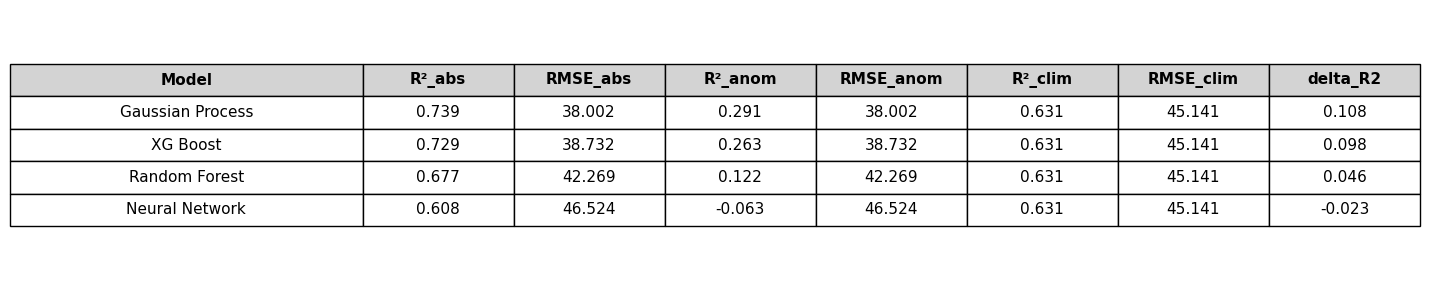

In [ ]:
plot_styled_table(summary)

In [ ]:
lead_cols = [c for c in results_df.columns if c.startswith("R²_mo")]

lead_skill = (
    results_df[results_df["Space"] == "anomaly"][["Model"] + lead_cols]
    .melt(id_vars="Model", var_name="lead", value_name="R²")
)

lead_skill["lead"] = lead_skill["lead"].str.replace("R²_mo", "").astype(int)
lead_skill = lead_skill.sort_values(["Model", "lead"])

#### Plot anomaly skill by lead month and method

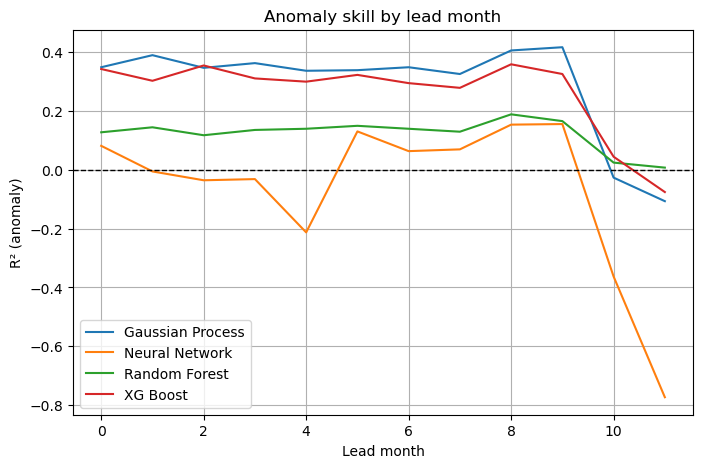

In [ ]:
plt.figure(figsize=(8,5))
for model, g in lead_skill.groupby("Model"):
    plt.plot(g["lead"], g["R²"], label=model)

plt.axhline(0, linewidth=1, color='black', linestyle='--')
plt.xlabel("Lead month")
plt.ylabel("R² (anomaly)")
plt.title("Anomaly skill by lead month")
plt.legend()
plt.grid(True)
plt.show()

### Plot skill score relative to climatology 

Current setup below will just run this analysis for the last model to be tested, so the results don't reflect the "best" modeling efforts necessarily

In [ ]:
summary = summary.assign(
    SkillScore=lambda d: 1 - d["RMSE_abs"] / d["RMSE_clim"]
)

summary.style.format({
    "R²_abs": "{:.3f}",
    "R²_clim": "{:.3f}",
    "delta_R2": "{:.3f}",
    "RMSE_abs": "{:.2f}",
    "RMSE_clim": "{:.2f}",
    "SkillScore": "{:.3f}"
})

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2,SkillScore
0,Gaussian Process,0.739,38.00,0.291000,38.002000,0.631,45.14,0.108,0.158
1,XG Boost,0.729,38.73,0.263000,38.732000,0.631,45.14,0.098,0.142
2,Random Forest,0.677,42.27,0.122000,42.269000,0.631,45.14,0.046,0.064
3,Neural Network,0.608,46.52,-0.063000,46.524000,0.631,45.14,-0.023,-0.031


In [ ]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def rmse_by_lead(y_true_df, y_pred_df):
    results = {}
    for lead in range(12):
        cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
        if not cols:
            continue
        
        yt = y_true_df[cols].to_numpy().ravel()
        yp = y_pred_df[cols].to_numpy().ravel()
        
        results[lead] = rmse(yt, yp)
        
    return results

In [ ]:
rmse_model = rmse_by_lead(y_true_abs, y_pred_abs)
rmse_clim  = rmse_by_lead(y_true_abs, y_clim_abs)

skill_by_lead = {
    lead: 1 - rmse_model[lead] / rmse_clim[lead]
    for lead in rmse_model
}

skill_by_lead_df = (
    pd.DataFrame({
        "lead": list(skill_by_lead.keys()),
        "SkillScore": list(skill_by_lead.values())
    })
    .sort_values("lead")
)

skill_by_lead_df

,lead,SkillScore
0,0,0.042482
1,1,-0.001830
2,2,-0.017246
3,3,-0.015008
4,4,-0.100276
5,5,0.067901
6,6,0.032542
7,7,0.036187
8,8,0.080403
9,9,0.081202


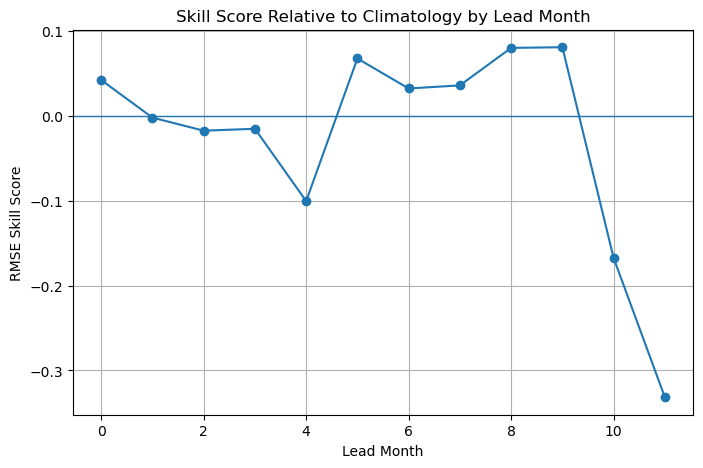

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(skill_by_lead_df["lead"], skill_by_lead_df["SkillScore"], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Lead Month")
plt.ylabel("RMSE Skill Score")
plt.title("Skill Score Relative to Climatology by Lead Month")
plt.grid(True)
plt.show()

In [ ]:
targets

,superior_target_evaporation,superior_target_precipitation,superior_target_runoff,superior_target_nbs,michigan-huron_target_evaporation,michigan-huron_target_precipitation,michigan-huron_target_runoff,michigan-huron_target_nbs,erie_target_evaporation,erie_target_precipitation,erie_target_runoff,erie_target_nbs,ontario_target_evaporation,ontario_target_precipitation,ontario_target_runoff,ontario_target_nbs
date,,,,,,,,,,,,,,,,
1950-01-01,125.357918,88.75,33.2,14.026862,95.709892,91.03,104.7,94.677343,38.810083,166.00,238.30,550.186890,75.883804,111.8,271.8,375.028505
1950-02-01,70.413371,36.98,25.5,-8.961299,59.667369,64.88,65.8,57.923217,40.703714,94.80,136.20,258.878682,77.272852,88.8,147.1,188.013699
1950-03-01,42.505142,62.08,31.0,49.607194,36.461632,77.05,81.9,124.142145,26.439582,97.00,162.60,427.763105,43.856645,71.4,196.6,323.419078
1950-04-01,25.310708,89.29,48.1,142.365472,23.005784,84.70,125.2,200.438931,16.345690,101.30,161.40,367.968263,17.753245,60.1,283.2,529.412835
1950-05-01,-8.965747,147.60,115.5,340.750102,0.003105,55.79,110.9,130.425081,10.834650,47.30,68.10,115.222385,2.194818,52.9,117.2,182.353310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,5.267900,73.93,36.0,83.476933,41.785871,84.30,33.5,38.130921,112.690526,101.69,20.42,24.484757,69.512130,84.0,40.7,22.364085
2022-09-01,50.655000,104.23,36.5,83.763871,76.020764,71.23,32.2,-21.176080,161.345409,88.97,25.36,-90.598246,88.009890,65.4,53.8,-39.955686
2022-10-01,81.158000,63.07,41.3,13.684743,87.836585,72.61,37.1,-2.383183,177.551294,50.74,17.61,-154.109940,84.626460,32.1,45.6,-46.448485


# Integrated NBS skill

Trying out 1, 3, and 6 month integrated NBS skill

In [ ]:
def compute_integrated_skill(
    y_true_df,
    y_pred_df,
    variable="superior_target_nbs",
    window=3
):
    """
    Compute skill on integrated (rolling-sum) lead windows.

    Parameters
    ----------
    y_true_df : pd.DataFrame
        Reconstructed absolute true values (with _mo{k} columns)

    y_pred_df : pd.DataFrame
        Reconstructed absolute predicted values

    variable : str
        Base variable name (e.g., 'superior_target_nbs')

    window : int
        Integration window (1, 3, 6 months)

    Returns
    -------
    float
        R² for integrated values
    """

    lead_cols = [
        f"{variable}_mo{k}" for k in range(12)
        if f"{variable}_mo{k}" in y_true_df.columns
    ]

    y_true_vals = y_true_df[lead_cols].values
    y_pred_vals = y_pred_df[lead_cols].values

    # rolling integration across lead axis
    integrated_true = []
    integrated_pred = []

    for start in range(len(lead_cols) - window + 1):
        integrated_true.append(
            y_true_vals[:, start:start+window].sum(axis=1)
        )
        integrated_pred.append(
            y_pred_vals[:, start:start+window].sum(axis=1)
        )

    integrated_true = np.concatenate(integrated_true)
    integrated_pred = np.concatenate(integrated_pred)

    return r2_score(integrated_true, integrated_pred)

In [ ]:
r2_1m = compute_integrated_skill(y_true_abs, y_pred_abs, window=1)
r2_3m = compute_integrated_skill(y_true_abs, y_pred_abs, window=3)
r2_6m = compute_integrated_skill(y_true_abs, y_pred_abs, window=6)

print("1-month:", r2_1m)
print("3-month:", r2_3m)
print("6-month:", r2_6m)

1-month: 0.6110774005334676
3-month: 0.729146907428884
6-month: 0.6331052233478097


In [ ]:
def compute_integrated_metrics(
    y_true_df,
    y_pred_df,
    y_clim_df,
    variable="superior_target_nbs",
    window=3
):
    """
    Compute integrated metrics for model and climatology baseline.

    Returns:
        dict with:
            r2_model
            r2_climatology
            skill_score
    """

    lead_cols = [
        f"{variable}_mo{k}" for k in range(12)
        if f"{variable}_mo{k}" in y_true_df.columns
    ]

    y_true_vals = y_true_df[lead_cols].values
    y_pred_vals = y_pred_df[lead_cols].values
    y_clim_vals = y_clim_df[lead_cols].values

    integrated_true = []
    integrated_pred = []
    integrated_clim = []

    for start in range(len(lead_cols) - window + 1):
        integrated_true.append(y_true_vals[:, start:start+window].sum(axis=1))
        integrated_pred.append(y_pred_vals[:, start:start+window].sum(axis=1))
        integrated_clim.append(y_clim_vals[:, start:start+window].sum(axis=1))

    integrated_true = np.concatenate(integrated_true)
    integrated_pred = np.concatenate(integrated_pred)
    integrated_clim = np.concatenate(integrated_clim)

    r2_model = r2_score(integrated_true, integrated_pred)
    r2_clim = r2_score(integrated_true, integrated_clim)

    mse_model = mean_squared_error(integrated_true, integrated_pred)
    mse_clim = mean_squared_error(integrated_true, integrated_clim)

    skill = 1 - (mse_model / mse_clim)

    return {
        "R2_model": r2_model,
        "R2_climatology": r2_clim,
        "Skill_vs_climatology": skill
    }

In [ ]:
for w in [1, 3, 6]:
    metrics = compute_integrated_metrics(
        y_true_abs,
        y_pred_abs,
        y_clim_abs,
        variable="superior_target_nbs",
        window=w
    )
    print(f"\n{w}-month integration")
    print(metrics)


1-month integration
{'R2_model': 0.6110774005334676, 'R2_climatology': 0.5996130134252748, 'Skill_vs_climatology': 0.028633266046605543}

3-month integration
{'R2_model': 0.729146907428884, 'R2_climatology': 0.7099203553596614, 'Skill_vs_climatology': 0.06628025242192048}

6-month integration
{'R2_model': 0.6331052233478097, 'R2_climatology': 0.6068860640728388, 'Skill_vs_climatology': 0.06669608192121912}


# Exploring integrated NBS Options

In [ ]:
def summarize_integrated_skill(
    y_true_abs,
    y_clim_abs,
    model_predictions,
    variable="superior_target_nbs",
    windows=(1, 3, 6)
):
    """
    Parameters
    ----------
    model_predictions : dict
        {"Model Name": y_pred_abs_df}
    """

    rows = []

    for model_name, y_pred_abs in model_predictions.items():
        for w in windows:

            metrics = compute_integrated_metrics(
                y_true_abs,
                y_pred_abs,
                y_clim_abs,
                variable=variable,
                window=w
            )

            rows.append({
                "Model": model_name,
                "Window (months)": w,
                "R2_model": round(metrics["R2_model"], 3),
                "R2_climatology": round(metrics["R2_climatology"], 3),
                "Skill_vs_climatology": round(metrics["Skill_vs_climatology"], 3)
            })

    return pd.DataFrame(rows)

In [ ]:
def build_eval_frames(y_test_scaled, y_pred_scaled, y_scaler, y_index, y_columns, scp_y):
    """
    Build evaluation DataFrames in three spaces:
      - anomaly (units after inverse StandardScaler)
      - absolute reconstructed (lead-aware climatology added back)
      - absolute climatology-only baseline (lead-aware)

    Returns
    -------
    dict with keys: 'anom', 'abs', 'clim_abs'
      each value is a pd.DataFrame shaped like (n_times, n_targets)
    """
    # 1) standardized -> anomaly units
    y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_index, y_columns)
    y_pred_anom = unscale_to_df(y_pred_scaled, y_scaler, y_index, y_columns)

    # 2) anomaly -> absolute (lead-aware)
    y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
    y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

    # 3) climatology-only baseline
    y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)

    return {
        "true_anom": y_true_anom,
        "pred_anom": y_pred_anom,
        "true_abs": y_true_abs,
        "pred_abs": y_pred_abs,
        "clim_abs": y_clim_abs,
    }

In [ ]:
frames_GP = build_eval_frames(y_test_scaled, y_pred_GP,  y_scaler, y_test.index, y_test.columns, scp_y)
frames_RF = build_eval_frames(y_test_scaled, y_pred_RFR, y_scaler, y_test.index, y_test.columns, scp_y)
frames_XGB = build_eval_frames(y_test_scaled, y_pred_XGB, y_scaler, y_test.index, y_test.columns, scp_y)
frames_NN = build_eval_frames(y_test_scaled, y_pred_NN,  y_scaler, y_test.index, y_test.columns, scp_y)

In [ ]:
def integrated_summary_for_models(frames_by_model, variable, windows=(1,3,6)):
    rows = []
    for model_name, fr in frames_by_model.items():
        for w in windows:
            m = compute_integrated_metrics(
                fr["true_abs"],
                fr["pred_abs"],
                fr["clim_abs"],
                variable=variable,
                window=w
            )
            rows.append({
                "Model": model_name,
                "Window": w,
                "R2_model": round(m["R2_model"], 3),
                "R2_clim": round(m["R2_climatology"], 3),
                "Skill": round(m["Skill_vs_climatology"], 3),
            })
    return pd.DataFrame(rows)

frames_by_model = {
    "Gaussian Process": frames_GP,
    "Random Forest": frames_RF,
    "XGBoost": frames_XGB,
    "Neural Network": frames_NN,
}

integrated_df = integrated_summary_for_models(
    frames_by_model,
    variable="superior_target_nbs",
    windows=(1,3,6)
)

integrated_df

,Model,Window,R2_model,R2_clim,Skill
0,Gaussian Process,1,0.792,0.600,0.481
1,Gaussian Process,3,0.886,0.710,0.606
2,Gaussian Process,6,0.871,0.607,0.671
3,Random Forest,1,0.646,0.600,0.115
4,Random Forest,3,0.764,0.710,0.185
5,Random Forest,6,0.713,0.607,0.269
6,XGBoost,1,0.756,0.600,0.390
7,XGBoost,3,0.857,0.710,0.506
8,XGBoost,6,0.809,0.607,0.514
9,Neural Network,1,0.611,0.600,0.029


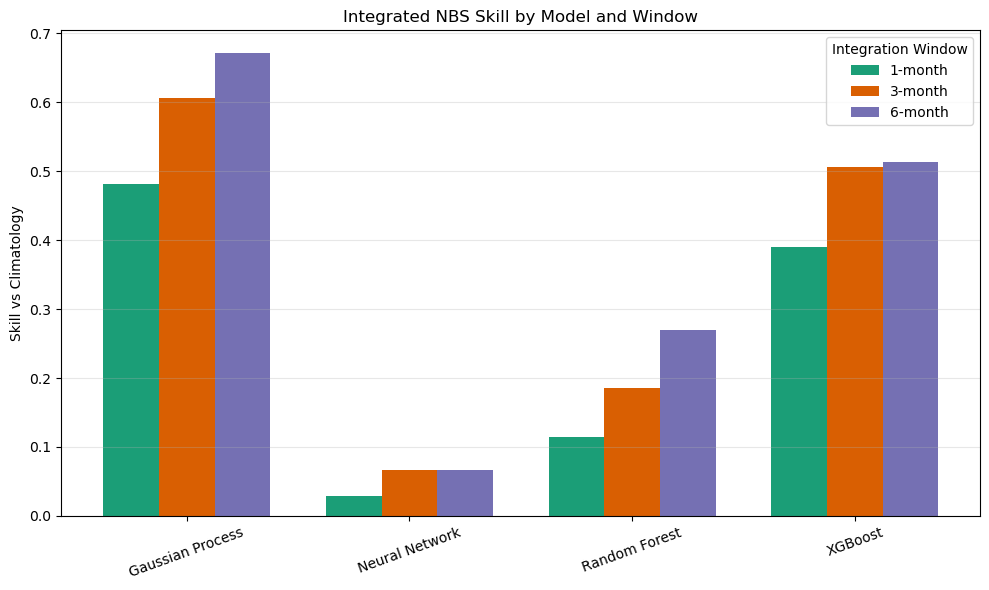

In [ ]:
skill_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="Skill"
).sort_index()

models = skill_pivot.index
windows = skill_pivot.columns

colors = ["#1b9e77", "#d95f02", "#7570b3"]  # Dark2

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        skill_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Skill vs Climatology")
ax.set_title("Integrated NBS Skill by Model and Window")
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

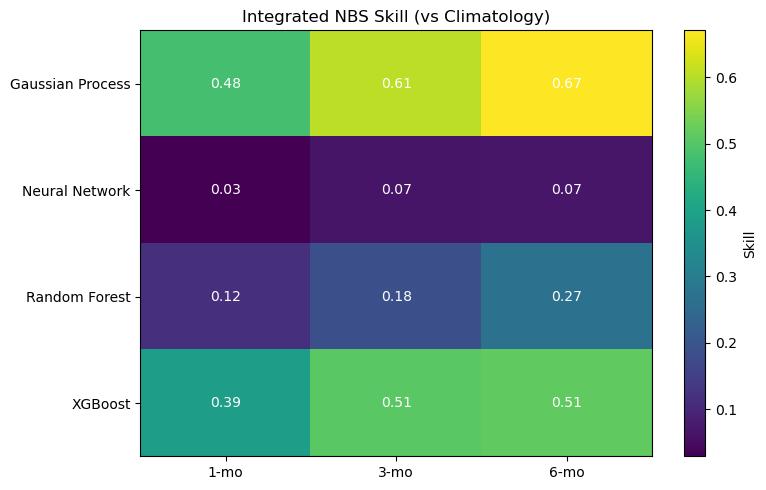

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

c = ax.imshow(skill_pivot.values, aspect='auto')

ax.set_xticks(range(len(windows)))
ax.set_xticklabels([f"{w}-mo" for w in windows])
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)

ax.set_title("Integrated NBS Skill (vs Climatology)")
plt.colorbar(c, label="Skill")

# Annotate cells
for i in range(len(models)):
    for j in range(len(windows)):
        ax.text(j, i, f"{skill_pivot.values[i, j]:.2f}",
                ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

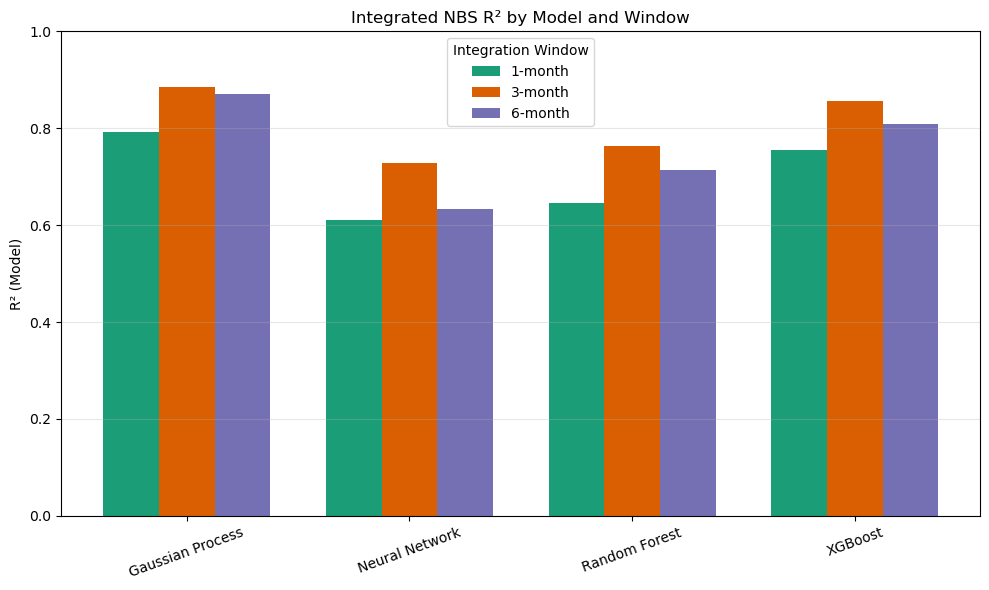

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

r2_model_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="R2_model"
).sort_index()

models = r2_model_pivot.index
windows = r2_model_pivot.columns

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        r2_model_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("R² (Model)")
ax.set_title("Integrated NBS R² by Model and Window")
ax.set_ylim(0, 1)
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

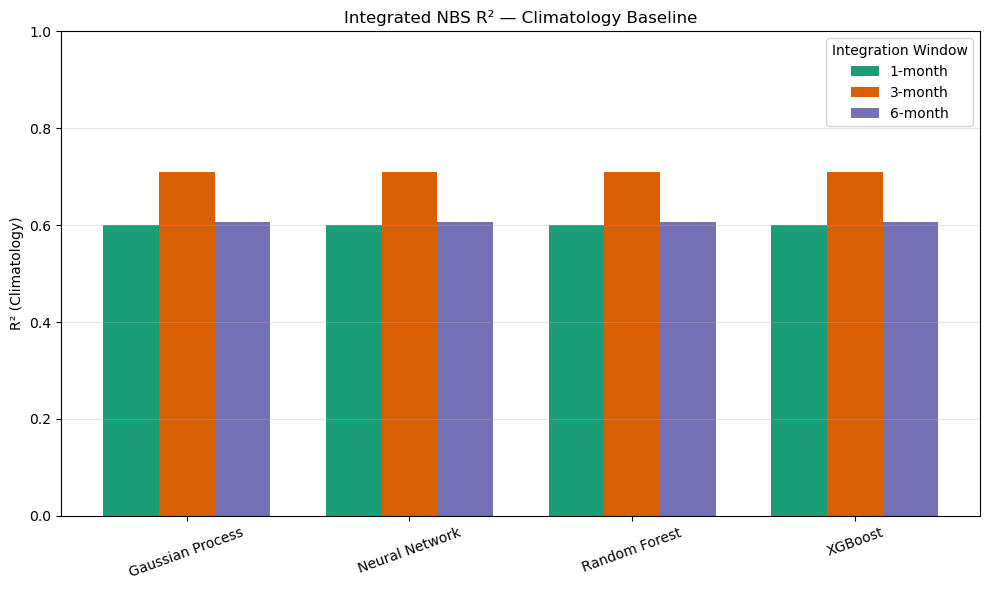

In [ ]:
r2_clim_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="R2_clim"
).sort_index()

models = r2_clim_pivot.index
windows = r2_clim_pivot.columns

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        r2_clim_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("R² (Climatology)")
ax.set_title("Integrated NBS R² — Climatology Baseline")
ax.set_ylim(0, 1)
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

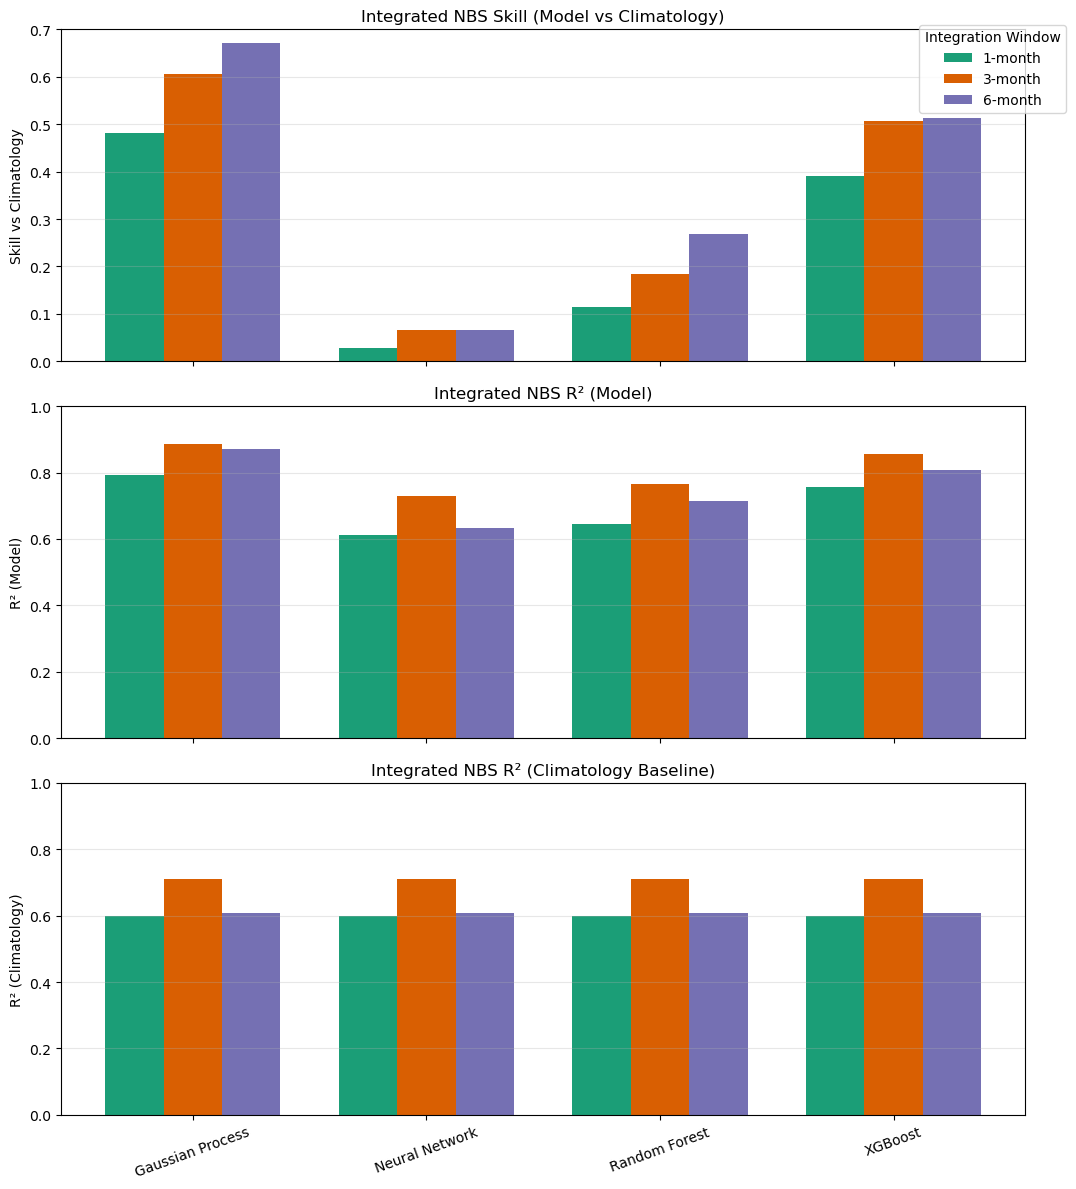

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["#1b9e77", "#d95f02", "#7570b3"]  # ColorBrewer Dark2 (colorblind-friendly)

def plot_grouped_bars(ax, pivot_df, ylabel, title, colors, ylim=(0, 1)):
    models = pivot_df.index
    windows = pivot_df.columns
    x = np.arange(len(models))
    width = 0.25

    for i, w in enumerate(windows):
        ax.bar(
            x + i*width - width,
            pivot_df[w].values,
            width,
            label=f"{w}-month",
            color=colors[i]
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20)

# Pivot tables
skill_pivot = integrated_df.pivot(index="Model", columns="Window", values="Skill").sort_index()
r2_model_pivot = integrated_df.pivot(index="Model", columns="Window", values="R2_model").sort_index()
r2_clim_pivot  = integrated_df.pivot(index="Model", columns="Window", values="R2_clim").sort_index()

# Create stacked figure
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 12), sharex=True)

plot_grouped_bars(
    axes[0], skill_pivot,
    ylabel="Skill vs Climatology",
    title="Integrated NBS Skill (Model vs Climatology)",
    colors=colors,
    ylim=(0, 0.7)  # skill is usually within [-inf, 1], but your range is positive and < 0.7
)

plot_grouped_bars(
    axes[1], r2_model_pivot,
    ylabel="R² (Model)",
    title="Integrated NBS R² (Model)",
    colors=colors,
    ylim=(0, 1)
)

plot_grouped_bars(
    axes[2], r2_clim_pivot,
    ylabel="R² (Climatology)",
    title="Integrated NBS R² (Climatology Baseline)",
    colors=colors,
    ylim=(0, 1)
)

# Put one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Integration Window", loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave space for legend
plt.show()